In [ ]:
import numpy as np
import scanpy as sc
import skmisc
import functions as fn
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
fullDataPath = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/data/sct_matrix_transposed.npz"
top5kDataPath = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/data/sct_top5k.npz"
fullData = np.load(fullDataPath)
top5kData = np.load(top5kDataPath)
# fullData is 51099 cells by 16647 genes
# top5kData is 5000 genes by 50929 cells

In [41]:
print(f"Full Data shape: {fullData['arr_0'].shape}, with keys: {list(fullData.keys())}")
print(f"Top 5k Data shape: {top5kData['data'].shape}, with keys: {list(top5kData.keys())}")
print(top5kData['genes'][:5])  # Check the content of 'cells' key

Full Data shape: (51099, 16647), with keys: ['arr_0']
Top 5k Data shape: (5000, 50929), with keys: ['data', 'genes', 'cells']
['REN' 'DEFB1' 'HBG2' 'HLA-DRA' 'HBA2']


In [ ]:
"# Convert top5kData['data'] from (genes x cells) to (cells x genes)
top5k_genes_x_cells = top5kData['data']            # shape: (G, C)
print("Original (genes x cells):", top5k_genes_x_cells.shape)

top5k_cells_x_genes = top5k_genes_x_cells.T        # view transpose, no copy unless modified
print("Transposed (cells x genes):", top5k_cells_x_genes.shape)

# Optional: keep convenient references to metadata (unchanged)
top5k_gene_names = top5kData['genes']
top5k_cell_ids = top5kData['cells']

# Sanity checks
assert top5k_cells_x_genes.shape == (len(top5k_cell_ids), len(top5k_gene_names))"

fullData_genes_x_cells = fullData['arr_0']    #full dataset is already in cell gene format, lacks annotations

Original (genes x cells): (5000, 50929)
Transposed (cells x genes): (50929, 5000)


In [32]:
# Percentage of non-zero values (memory-efficient counting)
full_nonzero_fraction = np.count_nonzero(full_matrix) / full_matrix.size
top5k_nonzero_fraction = np.count_nonzero(top5k_matrix) / top5k_matrix.size

print(f"Full dataset non-zero fraction: {full_nonzero_fraction:.4f} ({full_nonzero_fraction*100:.2f}%)")
print(f"Top5k dataset non-zero fraction: {top5k_nonzero_fraction:.4f} ({top5k_nonzero_fraction*100:.2f}%)")

Full dataset non-zero fraction: 0.0972 (9.72%)
Top5k dataset non-zero fraction: 0.1710 (17.10%)


In [90]:
def term_freq_bin(data, num_bins):
    #Get all non-zero values from the data
    non_zero_mask = np.nonzero(data)
    non_zero_vals = data[non_zero_mask]
    #calculate percentage of values that are non-zero
    non_zero_percentage = len(non_zero_vals) / data.size * 100 if data.size > 0 else 0
    print(f"Percentage of non-zero values: {non_zero_percentage:.2f}%")
    if len(non_zero_vals) == 0:
        return data

    # Calculate the edges of the bins
    bin_edges = np.linspace(non_zero_vals.min(), non_zero_vals.max(), num_bins+1)
    print("Bin edges:", bin_edges)
    #Using the bin edges, mask the original data values into bin number
    bin_vals = np.digitize(non_zero_vals, bin_edges, right=False)
    bin_vals[non_zero_vals == non_zero_vals.max()] = num_bins
    data[non_zero_mask] = bin_vals
    return data
    # Bin the top5k cells x genes matrix using global bin edges across all non-zero values
num_bins = 8
top5k_bins_tf = term_freq_bin(top5k_matrix.copy(), num_bins)

top5k_bins_tf_2 = term_freq_bin(top5k_matrix.copy(), 2)
top5k_bins_tf_80 = term_freq_bin(top5k_matrix.copy(), 80)
# Basic summary
unique_tf = np.unique(top5k_bins_tf[top5k_bins_tf > 0])
print(f"Non-zero bin labels present (should be 1..{num_bins}): {unique_tf}")
print("Binned matrix shape:", top5k_bins_tf.shape)

Percentage of non-zero values: 17.10%
Bin edges: [1.715243   2.32233761 2.92943222 3.53652683 4.14362143 4.75071604
 5.35781065 5.96490526 6.57199987]
Percentage of non-zero values: 17.10%
Bin edges: [1.715243   4.14362143 6.57199987]
Percentage of non-zero values: 17.10%
Bin edges: [1.715243   1.77595246 1.83666192 1.89737138 1.95808084 2.0187903
 2.07949976 2.14020923 2.20091869 2.26162815 2.32233761 2.38304707
 2.44375653 2.50446599 2.56517545 2.62588491 2.68659437 2.74730383
 2.8080133  2.86872276 2.92943222 2.99014168 3.05085114 3.1115606
 3.17227006 3.23297952 3.29368898 3.35439844 3.4151079  3.47581736
 3.53652683 3.59723629 3.65794575 3.71865521 3.77936467 3.84007413
 3.90078359 3.96149305 4.02220251 4.08291197 4.14362143 4.20433089
 4.26504036 4.32574982 4.38645928 4.44716874 4.5078782  4.56858766
 4.62929712 4.69000658 4.75071604 4.8114255  4.87213496 4.93284443
 4.99355389 5.05426335 5.11497281 5.17568227 5.23639173 5.29710119
 5.35781065 5.41852011 5.47922957 5.53993903 5.6

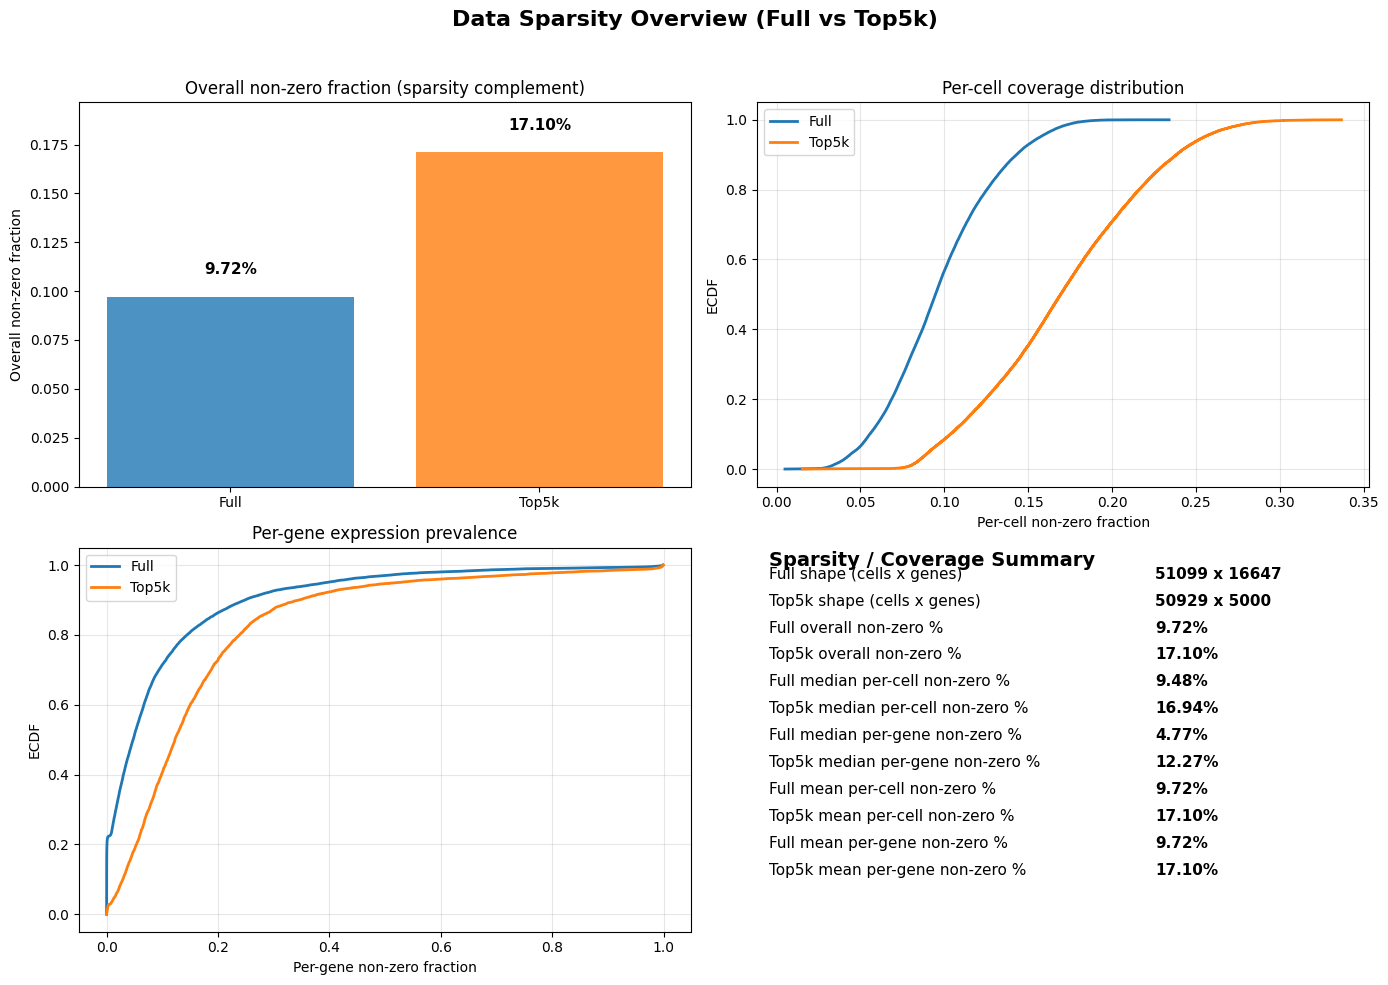

In [33]:
# Sparsity visualisation (overall + per-cell + per-gene) with annotated values

# Use existing precomputed fractions to avoid recomputation
full_cell_nz_frac = 1 - full_cell_zero_frac
top_cell_nz_frac  = 1 - top5k_cell_zero_frac
full_gene_nz_frac = 1 - full_gene_zero_frac
top_gene_nz_frac  = 1 - top5k_gene_zero_frac

fig_sparsity, axes_sparsity = plt.subplots(2, 2, figsize=(14, 10))
(ax_bar, ax_ecdf_cells), (ax_ecdf_genes, ax_table) = axes_sparsity

# 1. Overall non-zero fraction (bars)
overall_labels = ["Full", "Top5k"]
overall_values = [full_nonzero_fraction, top5k_nonzero_fraction]
bar_colors = ["tab:blue", "tab:orange"]
bars = ax_bar.bar(overall_labels, overall_values, color=bar_colors, alpha=0.8)
ax_bar.set_ylim(0, max(overall_values)*1.15)
ax_bar.set_ylabel("Overall non-zero fraction")
ax_bar.set_title("Overall non-zero fraction (sparsity complement)")
for b, v in zip(bars, overall_values):
    ax_bar.text(b.get_x() + b.get_width()/2, v + 0.01,
                f"{v:.2%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# 2. ECDF of per-cell non-zero fraction
def plot_ecdf(data, ax, label, color, max_points=60_000):
    d = data
    if d.size > max_points:
        idx = rng.choice(d.size, size=max_points, replace=False)
        d = d[idx]
    d_sorted = np.sort(d)
    y = np.linspace(0, 1, d_sorted.size)
    ax.plot(d_sorted, y, label=label, color=color, lw=2)

plot_ecdf(full_cell_nz_frac, ax_ecdf_cells, "Full", "tab:blue")
plot_ecdf(top_cell_nz_frac,  ax_ecdf_cells, "Top5k", "tab:orange")
ax_ecdf_cells.set_xlabel("Per-cell non-zero fraction")
ax_ecdf_cells.set_ylabel("ECDF")
ax_ecdf_cells.set_title("Per-cell coverage distribution")
ax_ecdf_cells.legend()
ax_ecdf_cells.grid(alpha=0.3)

# 3. ECDF of per-gene non-zero fraction
plot_ecdf(full_gene_nz_frac, ax_ecdf_genes, "Full", "tab:blue")
plot_ecdf(top_gene_nz_frac,  ax_ecdf_genes, "Top5k", "tab:orange")
ax_ecdf_genes.set_xlabel("Per-gene non-zero fraction")
ax_ecdf_genes.set_ylabel("ECDF")
ax_ecdf_genes.set_title("Per-gene expression prevalence")
ax_ecdf_genes.legend()
ax_ecdf_genes.grid(alpha=0.3)

# 4. Metrics table (text)
ax_table.axis("off")
metrics = [
    ("Full shape (cells x genes)", f"{full_matrix.shape[0]} x {full_matrix.shape[1]}"),
    ("Top5k shape (cells x genes)", f"{top5k_matrix.shape[0]} x {top5k_matrix.shape[1]}"),
    ("Full overall non-zero %", f"{full_nonzero_fraction*100:.2f}%"),
    ("Top5k overall non-zero %", f"{top5k_nonzero_fraction*100:.2f}%"),
    ("Full median per-cell non-zero %", f"{np.median(full_cell_nz_frac)*100:.2f}%"),
    ("Top5k median per-cell non-zero %", f"{np.median(top_cell_nz_frac)*100:.2f}%"),
    ("Full median per-gene non-zero %", f"{np.median(full_gene_nz_frac)*100:.2f}%"),
    ("Top5k median per-gene non-zero %", f"{np.median(top_gene_nz_frac)*100:.2f}%"),
    ("Full mean per-cell non-zero %", f"{full_cell_nz_frac.mean()*100:.2f}%"),
    ("Top5k mean per-cell non-zero %", f"{top_cell_nz_frac.mean()*100:.2f}%"),
    ("Full mean per-gene non-zero %", f"{full_gene_nz_frac.mean()*100:.2f}%"),
    ("Top5k mean per-gene non-zero %", f"{top_gene_nz_frac.mean()*100:.2f}%"),
]

y0 = 0.95
dy = 0.07
ax_table.text(0.02, 0.99, "Sparsity / Coverage Summary", fontsize=14, fontweight="bold", va="top")
for i, (k, v) in enumerate(metrics):
    ax_table.text(0.02, y0 - i*dy, k, fontsize=11, ha="left", va="top")
    ax_table.text(0.65, y0 - i*dy, v, fontsize=11, ha="left", va="top", fontweight="bold")

fig_sparsity.suptitle("Data Sparsity Overview (Full vs Top5k)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])

Full matrix shape: (51099, 16647)
Top5k matrix shape: (50929, 5000)
Overall zero fraction (Full):  0.903
Overall zero fraction (Top5k): 0.829
Preparing AnnData objects (this may take a moment)...


c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


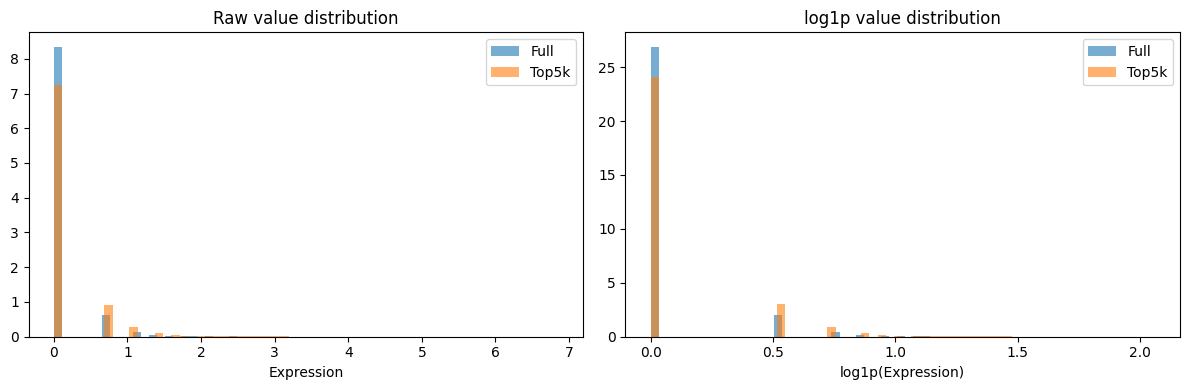

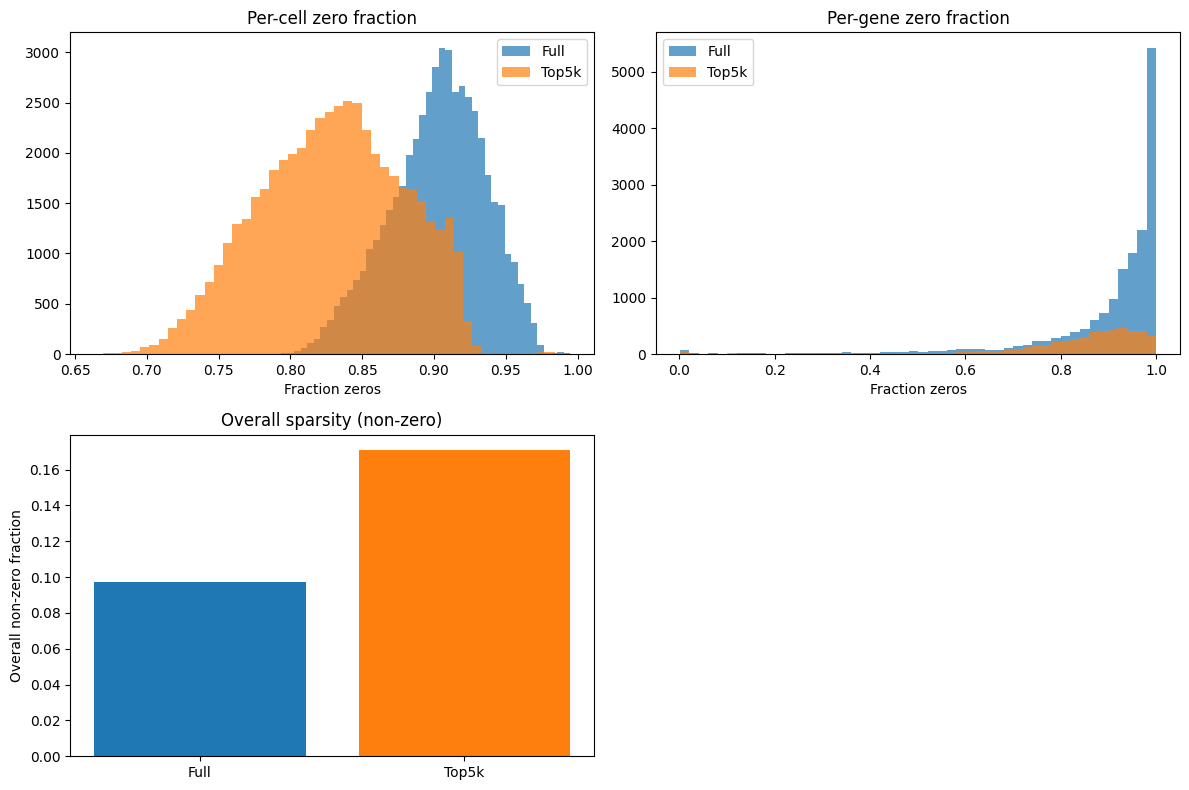

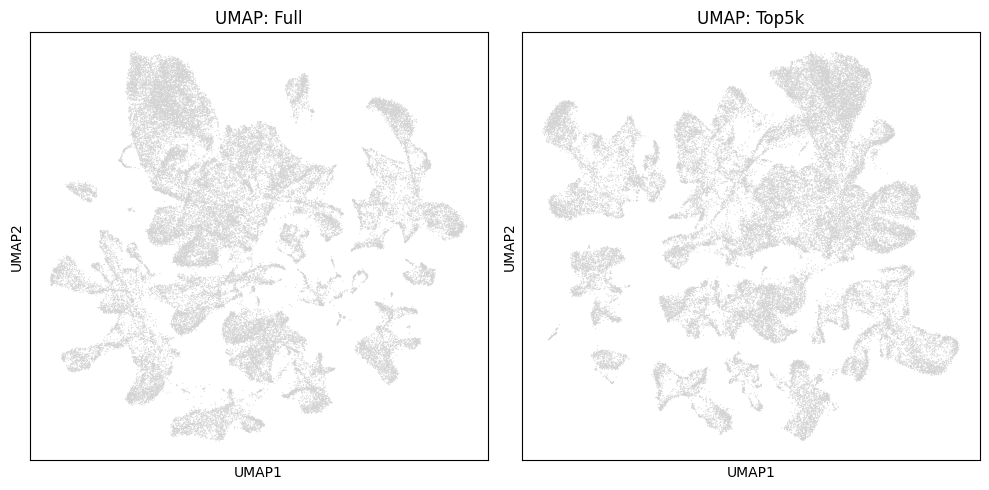

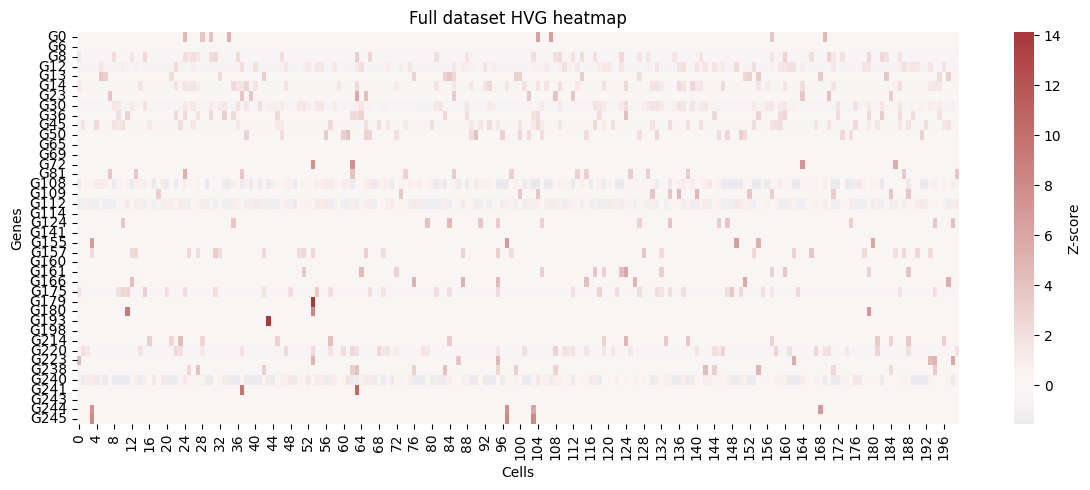

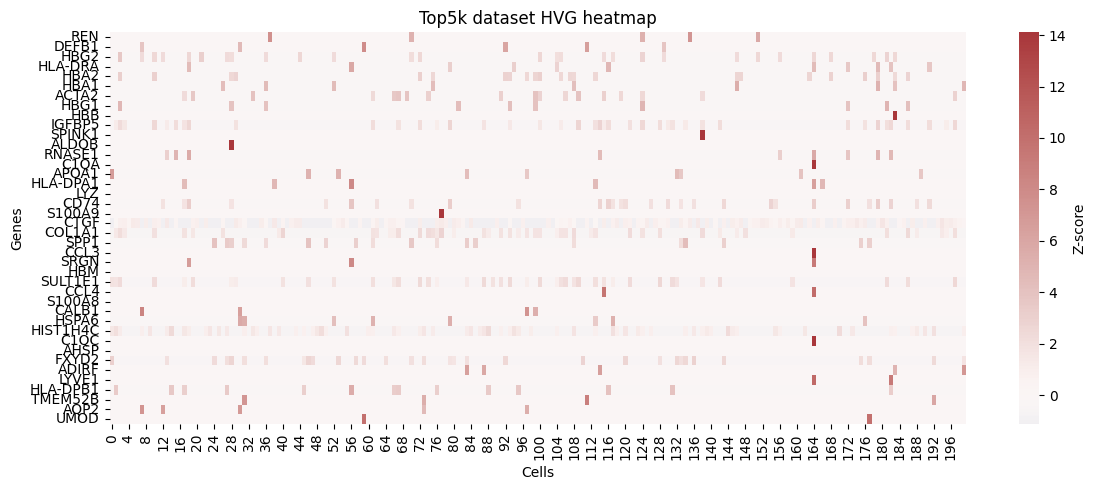

In [ ]:

# Ensure scanpy is available (needed for AnnData processing

# Visualization & comparative analysis for full dataset vs top5k subset


# 1. Access matrices (full: cells x genes, top5k already transposed in cell 3)
full_matrix = fullData['arr_0']                 # shape: (cells_full, genes_full)
top5k_matrix = top5k_cells_x_genes              # shape: (cells_top5k, 5000)

# 2. Basic summaries
print(f"Full matrix shape: {full_matrix.shape}")
print(f"Top5k matrix shape: {top5k_matrix.shape}")

# 3. Value distributions (sample to keep plotting reasonable)
def sample_values(arr, max_samples=1_000_000):
    flat = arr.ravel()
    if flat.size > max_samples:
        idx = rng.choice(flat.size, size=max_samples, replace=False)
        flat = flat[idx]
    return flat

full_vals  = sample_values(full_matrix)
top5k_vals = sample_values(top5k_matrix)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = 60
axes[0].hist(full_vals, bins=bins, alpha=0.6, label='Full', density=True)
axes[0].hist(top5k_vals, bins=bins, alpha=0.6, label='Top5k', density=True)
axes[0].set_title("Raw value distribution")
axes[0].set_xlabel("Expression")
axes[0].legend()

axes[1].hist(np.log1p(full_vals), bins=bins, alpha=0.6, label='Full', density=True)
axes[1].hist(np.log1p(top5k_vals), bins=bins, alpha=0.6, label='Top5k', density=True)
axes[1].set_title("log1p value distribution")
axes[1].set_xlabel("log1p(Expression)")
axes[1].legend()
plt.tight_layout()

# 4. Zero vs non-zero distributions
full_cell_zero_frac  = (full_matrix == 0).mean(axis=1)
top5k_cell_zero_frac = (top5k_matrix == 0).mean(axis=1)
full_gene_zero_frac  = (full_matrix == 0).mean(axis=0)
top5k_gene_zero_frac = (top5k_matrix == 0).mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(full_cell_zero_frac, bins=50, alpha=0.7, label='Full')
axes[0,0].hist(top5k_cell_zero_frac, bins=50, alpha=0.7, label='Top5k')
axes[0,0].set_title("Per-cell zero fraction")
axes[0,0].set_xlabel("Fraction zeros"); axes[0,0].legend()

axes[0,1].hist(full_gene_zero_frac, bins=50, alpha=0.7, label='Full')
axes[0,1].hist(top5k_gene_zero_frac, bins=50, alpha=0.7, label='Top5k')
axes[0,1].set_title("Per-gene zero fraction")
axes[0,1].set_xlabel("Fraction zeros"); axes[0,1].legend()

axes[1,0].bar(['Full','Top5k'], [1 - (full_matrix==0).mean(), 1 - (top5k_matrix==0).mean()], color=['C0','C1'])
axes[1,0].set_ylabel("Overall non-zero fraction")
axes[1,0].set_title("Overall sparsity (non-zero)")

axes[1,1].axis('off')
plt.tight_layout()

print(f"Overall zero fraction (Full):  {(full_matrix==0).mean():.3f}")
print(f"Overall zero fraction (Top5k): {(top5k_matrix==0).mean():.3f}")

# 5. Build AnnData objects & UMAP
def build_adata(mat, gene_names=None, cell_ids=None, n_hvg=3000):
    ad = sc.AnnData(mat)
    if gene_names is not None:
        ad.var_names = gene_names.astype(str)
    else:
        # fabricate names if absent
        ad.var_names = [f"G{i}" for i in range(ad.n_vars)]
    if cell_ids is not None:
        ad.obs_names = cell_ids.astype(str)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    sc.pp.highly_variable_genes(ad, n_top_genes=min(n_hvg, ad.n_vars), flavor='seurat_v3')
    ad = ad[:, ad.var['highly_variable']].copy()
    sc.pp.scale(ad, zero_center=True, max_value=10)
    sc.tl.pca(ad, n_comps=50, svd_solver='arpack')
    sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)
    sc.tl.umap(ad, random_state=0)
    return ad

print("Preparing AnnData objects (this may take a moment)...")
full_adata  = build_adata(full_matrix, n_hvg=3000)
top5k_adata = build_adata(top5k_matrix, gene_names=top5k_gene_names, cell_ids=top5k_cell_ids, n_hvg=3000)

fig, axes = plt.subplots(1, 2, figsize=(10,5))
sc.pl.umap(full_adata, ax=axes[0], show=False, title="UMAP: Full")
sc.pl.umap(top5k_adata, ax=axes[1], show=False, title="UMAP: Top5k")
plt.tight_layout()

# 6. Heatmaps of expression (top HVGs, sampled cells)
def heatmap_subset(adata, n_genes=40, n_cells=200, title="Heatmap"):
    hvg_genes = adata.var[adata.var['highly_variable']].index[:n_genes]
    if adata.n_obs > n_cells:
        sampled_cells = rng.choice(adata.n_obs, size=n_cells, replace=False)
    else:
        sampled_cells = np.arange(adata.n_obs)
    sub = adata[sampled_cells, hvg_genes]
    m = sub.X
    if not isinstance(m, np.ndarray):
        m = m.A
    # z-score per gene for visualization
    m_z = (m - m.mean(axis=0)) / (m.std(axis=0) + 1e-6)
    plt.figure(figsize=(12,5))
    sns.heatmap(m_z.T, cmap="vlag", center=0,
                cbar_kws={"label": "Z-score"},
                yticklabels=hvg_genes)
    plt.title(title)
    plt.xlabel("Cells")
    plt.ylabel("Genes")
    plt.tight_layout()

heatmap_subset(full_adata, title="Full dataset HVG heatmap")
heatmap_subset(top5k_adata, title="Top5k dataset HVG heatmap")

Gene rank top-20 overlap (Full subset): 19
Gene rank top-20 overlap (Top5k subset): 19
Category fractions Full: [0.89644875 0.034225   0.03410125 0.035225  ]
Category fractions Top5k: [0.8210025  0.05913375 0.05897875 0.060885  ]
Done: discretisation visualisations created.


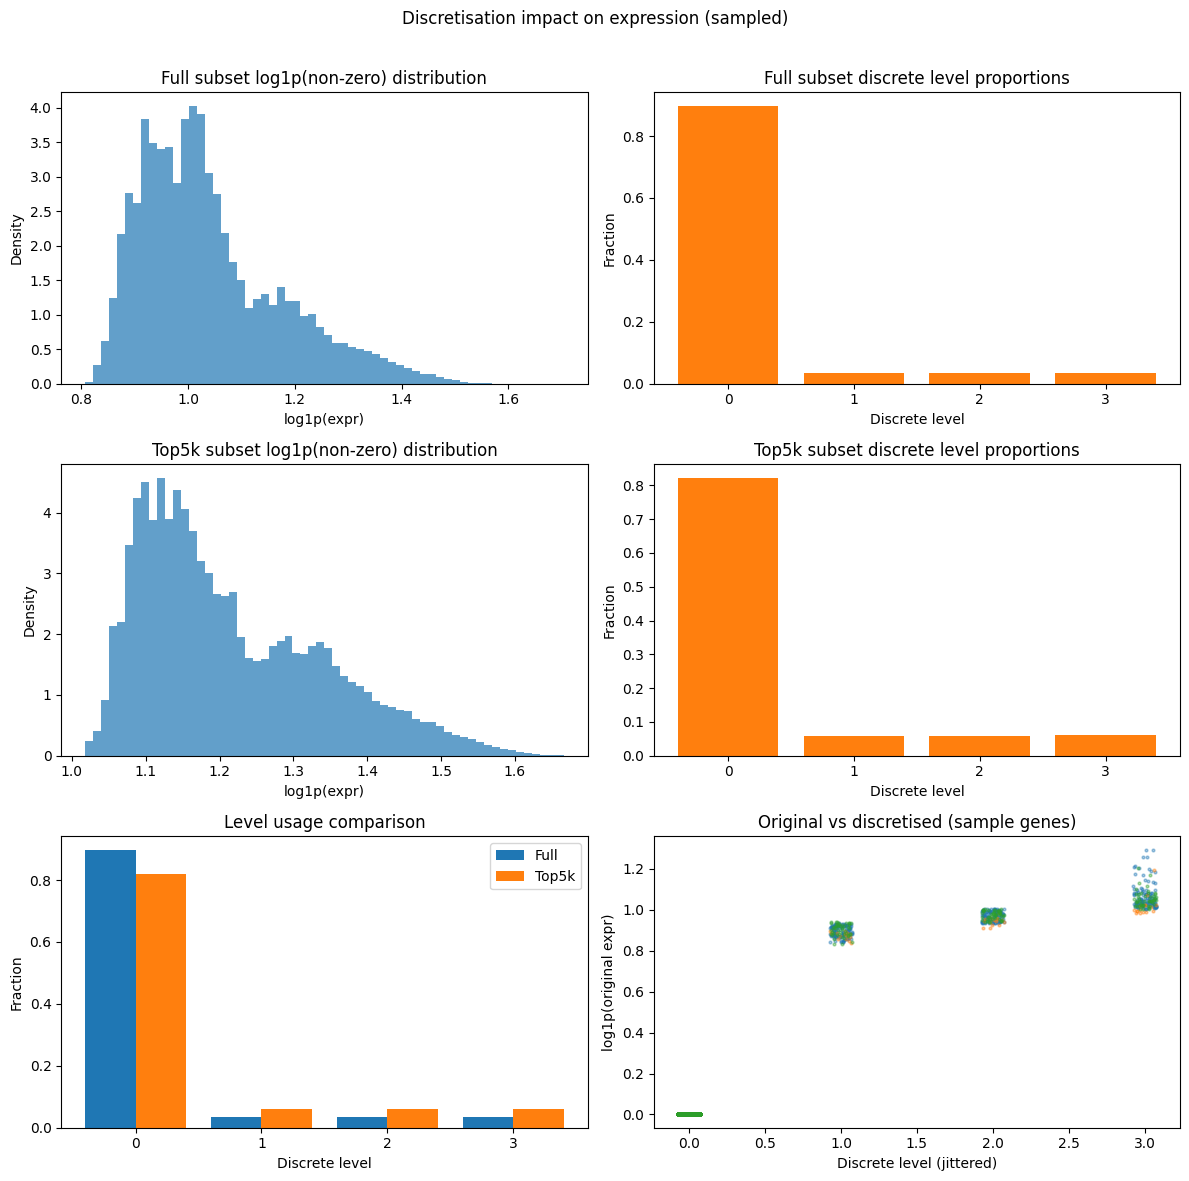

In [24]:
# Visualise effect of discretising expression to reduce noise while retaining structure

# Strategy:
# 1. Sample a manageable subset of cells & genes from each dataset.
# 2. Build a 4-level discrete representation per gene:
#    0 = zero, 1 = low (0-33%), 2 = mid (33-66%), 3 = high (66-100%) among non-zero values (per gene, on the sample).
#    Genes with too few non-zero values collapse to {0,1}.
# 3. Compare distributions, category proportions, and preservation of gene ranking.

def discretize_per_gene(mat_subset):
    """
    mat_subset: (cells x genes) dense numpy array (subset)
    Returns discrete_mat (uint8), thresholds list (per gene)
    """
    n_cells, n_genes = mat_subset.shape
    disc = np.zeros_like(mat_subset, dtype=np.uint8)
    thresholds = []
    for g in range(n_genes):
        col = mat_subset[:, g]
        nz = col[col > 0]
        if nz.size < 10:
            # Only distinguish zero vs non-zero
            disc[col > 0, g] = 1
            thresholds.append([])
            continue
        # Quantile thresholds on non-zero values
        q1, q2 = np.quantile(nz, [0.33, 0.66])
        # Assign bins
        # zeros stay 0
        mask_nz = col > 0
        nz_vals = col[mask_nz]
        bins = np.zeros(nz_vals.shape, dtype=np.uint8)
        bins[nz_vals <= q1] = 1
        bins[(nz_vals > q1) & (nz_vals <= q2)] = 2
        bins[nz_vals > q2] = 3
        disc[mask_nz, g] = bins
        thresholds.append([q1, q2])
    return disc, thresholds

def sample_subset(mat, n_cells=4000, n_genes=200):
    nC, nG = mat.shape
    scells = rng.choice(nC, size=min(n_cells, nC), replace=False)
    sgenes = rng.choice(nG, size=min(n_genes, nG), replace=False)
    return scells, sgenes, mat[np.ix_(scells, sgenes)]

# Sample subsets
full_cells_idx, full_genes_idx, full_sub = sample_subset(full_matrix, n_cells=4000, n_genes=200)
top_cells_idx,  top_genes_idx,  top_sub  = sample_subset(top5k_matrix, n_cells=4000, n_genes=200)

# Discretise
full_disc, full_thr = discretize_per_gene(full_sub)
top_disc,  top_thr  = discretize_per_gene(top_sub)

# Helper metrics
def gene_rank_overlap(orig, disc, top_k=20):
    # Mean per gene
    orig_means = orig.mean(axis=0)
    # Map discrete levels to midpoints to approximate continuity
    level_map = np.array([0.0, 0.2, 0.5, 0.8])
    disc_means = (level_map[disc]).mean(axis=0)
    orig_rank = np.argsort(-orig_means)[:top_k]
    disc_rank = np.argsort(-disc_means)[:top_k]
    overlap = len(set(orig_rank).intersection(disc_rank))
    return overlap, orig_rank, disc_rank

full_overlap, _, _ = gene_rank_overlap(full_sub, full_disc)
top_overlap,  _, _ = gene_rank_overlap(top_sub,  top_disc)

# Build figures
fig_disc, axes_disc = plt.subplots(3, 2, figsize=(12, 12))
fig_disc.suptitle("Discretisation impact on expression (sampled)")

# 1. Distribution of non-zero values vs discrete levels
def plot_value_distribution(ax_raw, ax_disc, sub_mat, disc_mat, title):
    nz = sub_mat[sub_mat > 0]
    # Cap very large arrays
    if nz.size > 200_000:
        nz = rng.choice(nz, size=200_000, replace=False)
    ax_raw.hist(np.log1p(nz), bins=60, color="tab:blue", alpha=0.7, density=True)
    ax_raw.set_title(f"{title} log1p(non-zero) distribution")
    ax_raw.set_xlabel("log1p(expr)")
    ax_raw.set_ylabel("Density")
    # Discrete frequencies
    vals, counts = np.unique(disc_mat, return_counts=True)
    freq = counts / counts.sum()
    ax_disc.bar(vals, freq, color="tab:orange")
    ax_disc.set_xticks([0,1,2,3])
    ax_disc.set_xlabel("Discrete level")
    ax_disc.set_ylabel("Fraction")
    ax_disc.set_title(f"{title} discrete level proportions")

plot_value_distribution(axes_disc[0,0], axes_disc[0,1], full_sub, full_disc, "Full subset")
plot_value_distribution(axes_disc[1,0], axes_disc[1,1], top_sub,  top_disc,  "Top5k subset")

# 2. Category proportion comparison (stacked bars)
def category_proportions(disc):
    levels, cnt = np.unique(disc, return_counts=True)
    out = np.zeros(4)
    out[levels] = cnt
    return out / out.sum()

full_props = category_proportions(full_disc)
top_props  = category_proportions(top_disc)

ax = axes_disc[2,0]
width = 0.4
x = np.arange(4)
ax.bar(x - width/2, full_props, width=width, label="Full")
ax.bar(x + width/2, top_props,  width=width, label="Top5k")
ax.set_xticks(x)
ax.set_xlabel("Discrete level")
ax.set_ylabel("Fraction")
ax.set_title("Level usage comparison")
ax.legend()

# 3. Gene examples: original vs discretised (scatter with jitter)
example_genes = full_genes_idx[:3]  # first 3 sampled genes from full
ax2 = axes_disc[2,1]
jitter_scale = 0.15
for i, gidx in enumerate(example_genes):
    orig_vals = full_sub[:, i]
    disc_vals = full_disc[:, i]
    # sample for clarity
    if orig_vals.size > 4000:
        sel = rng.choice(orig_vals.size, size=4000, replace=False)
        orig_vals = orig_vals[sel]
        disc_vals = disc_vals[sel]
    ax2.scatter(
        disc_vals + (rng.random(size=disc_vals.size)-0.5)*jitter_scale,
        np.log1p(orig_vals),
        s=4,
        alpha=0.4,
        label=f"Gene {i}" if i == 0 else None
    )
ax2.set_xlabel("Discrete level (jittered)")
ax2.set_ylabel("log1p(original expr)")
ax2.set_title("Original vs discretised (sample genes)")

plt.tight_layout(rect=[0,0,1,0.97])

print("Gene rank top-20 overlap (Full subset):", full_overlap)
print("Gene rank top-20 overlap (Top5k subset):", top_overlap)
print("Category fractions Full:", full_props)
print("Category fractions Top5k:", top_props)
print("Done: discretisation visualisations created.")

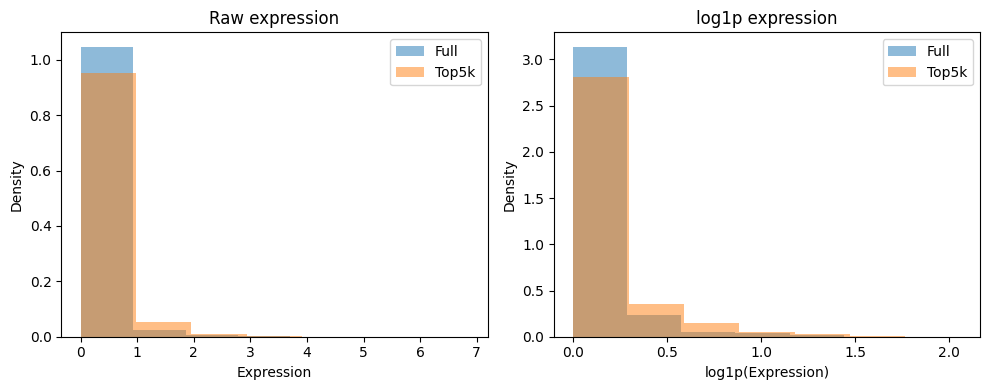

In [28]:
# Histogram of full vs top5k expression values (raw + log1p)
fig_hist, ax_hist = plt.subplots(1, 2, figsize=(10, 4))
# Raw
ax_hist[0].hist(full_vals,  bins=bins, alpha=0.5, label='Full',  density=True)
ax_hist[0].hist(top5k_vals, bins=bins, alpha=0.5, label='Top5k', density=True)
ax_hist[0].set_title("Raw expression")
ax_hist[0].set_xlabel("Expression")
ax_hist[0].set_ylabel("Density")
ax_hist[0].legend()

# log1p
ax_hist[1].hist(np.log1p(full_vals),  bins=bins, alpha=0.5, label='Full',  density=True)
ax_hist[1].hist(np.log1p(top5k_vals), bins=bins, alpha=0.5, label='Top5k', density=True)
ax_hist[1].set_title("log1p expression")
ax_hist[1].set_xlabel("log1p(Expression)")
ax_hist[1].set_ylabel("Density")
ax_hist[1].legend()

plt.tight_layout()

Non-zero samples -> Full: 300000, Top5k: 300000


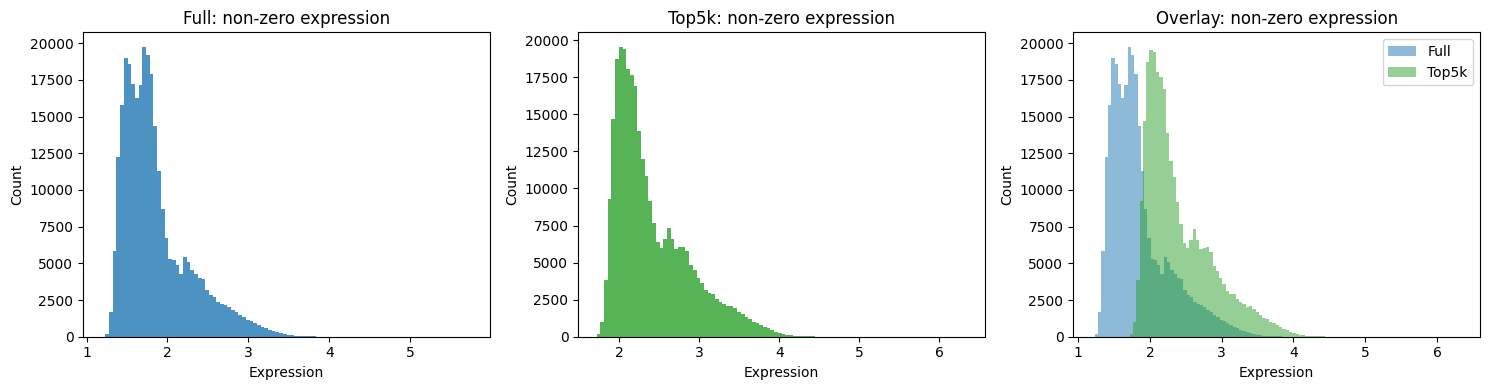

In [36]:
# Histograms of non-zero expression values (raw) for each dataset + overlay

def get_nonzero_sample(mat, max_samples=300_000, rng=rng):
    """
    Return (up to) max_samples non-zero entries from matrix (flattened).
    """
    nz = mat[mat > 0]
    if nz.size > max_samples:
        idx = rng.choice(nz.size, size=max_samples, replace=False)
        nz = nz[idx]
    return nz

def plot_nonzero_histograms(
    mat_a,
    mat_b,
    label_a="Dataset A",
    label_b="Dataset B",
    bins=60,
    max_samples=300_000,
    density=True,
    figsize=(15, 4)
):
    """
    Plot per-dataset non-zero value histograms and an overlay.

    Returns:
        fig, axes, nz_a, nz_b
    """
    nz_a = get_nonzero_sample(mat_a, max_samples=max_samples)
    nz_b = get_nonzero_sample(mat_b, max_samples=max_samples)

    print(f"Non-zero samples -> {label_a}: {nz_a.size}, {label_b}: {nz_b.size}")

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].hist(nz_a, bins=bins, color="tab:blue", alpha=0.8, density=density)
    axes[0].set_title(f"{label_a}: non-zero expression")
    axes[0].set_xlabel("Expression")
    axes[0].set_ylabel("Density" if density else "Count")

    axes[1].hist(nz_b, bins=bins, color="tab:green", alpha=0.8, density=density)
    axes[1].set_title(f"{label_b}: non-zero expression")
    axes[1].set_xlabel("Expression")
    axes[1].set_ylabel("Density" if density else "Count")

    axes[2].hist(nz_a, bins=bins, alpha=0.5, density=density, label=label_a, color="tab:blue")
    axes[2].hist(nz_b, bins=bins, alpha=0.5, density=density, label=label_b, color="tab:green")
    axes[2].set_title("Overlay: non-zero expression")
    axes[2].set_xlabel("Expression")
    axes[2].set_ylabel("Density" if density else "Count")
    axes[2].legend()

    plt.tight_layout()
    return fig, axes, nz_a, nz_b

# Example usage (recreates previous figure):
fig_nonzero, axes_nonzero, full_nz_raw, top5k_nz_raw = plot_nonzero_histograms(
    full_matrix,
    top5k_matrix,
    label_a="Full",
    label_b="Top5k",
    bins=100,    
    density=False,
    max_samples=300_000
)

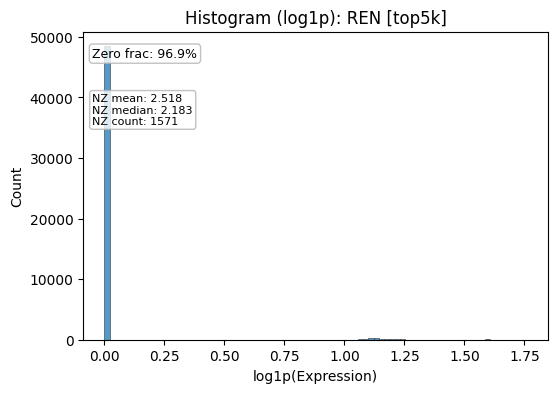

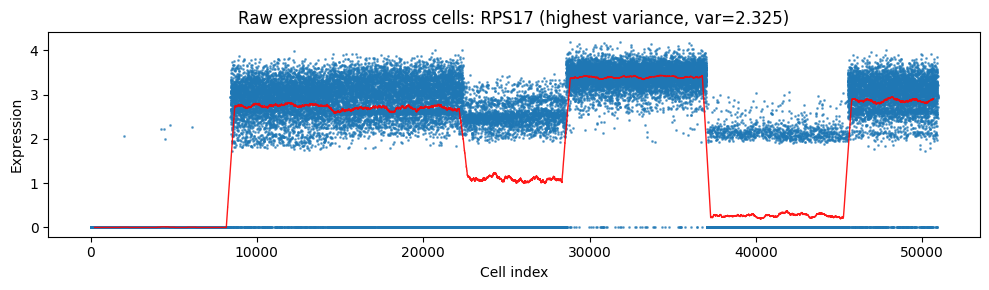

In [39]:
def plot_gene_expression(
    gene,
    dataset="top5k",
    bins=60,
    bin_width=None,
    log=False,
    cumulative=False,
    max_cells=None,
    density=True,
    zero_bar=True,
    ax=None,
    title=None
):
    """
    Plot expression distribution for a single gene across cells.

    Parameters
    ----------
    gene : int or str
        Gene index (int) or gene name (str). Gene names only available for dataset='top5k'
        unless you pass a pre-aligned gene_names array explicitly (see below).
    dataset : {'top5k','full'}
        Which matrix to use. 'top5k' uses top5k_matrix; 'full' uses full_matrix.
    bins : int
        Number of histogram bins (ignored if bin_width is provided).
    bin_width : float or None
        If provided, overrides `bins` by computing number of bins = ceil((max-min)/bin_width).
    log : bool
        If True, apply log1p transform before plotting.
    cumulative : bool
        If True, draw cumulative histogram (CDF).
    max_cells : int or None
        If set, randomly subsample this many cells for speed.
    density : bool
        Density (pdf) vs raw counts.
    zero_bar : bool
        If True, annotate fraction of zero entries.
    ax : matplotlib Axes or None
        Reuse an axes; if None create a new figure.
    title : str or None
        Custom plot title.

    Returns
    -------
    ax : matplotlib Axes
    """
    # Select matrix
    if dataset == "top5k":
        mat = top5k_matrix
        gene_names = top5k_gene_names
    elif dataset == "full":
        mat = full_matrix
        gene_names = None  # not available
    else:
        raise ValueError("dataset must be 'top5k' or 'full'")

    # Resolve gene index
    if isinstance(gene, str):
        if gene_names is None:
            raise ValueError("Gene names unavailable for full dataset; provide an integer index.")
        matches = np.where(gene_names == gene)[0]
        if matches.size == 0:
            raise ValueError(f"Gene '{gene}' not found in selected dataset.")
        gidx = matches[0]
        gene_label = gene
    else:
        gidx = int(gene)
        if gidx < 0 or gidx >= mat.shape[1]:
            raise IndexError(f"Gene index {gidx} out of range (0..{mat.shape[1]-1}).")
        gene_label = gene_names[gidx] if gene_names is not None else f"G{gidx}"

    # Extract expression vector
    expr = mat[:, gidx]

    # Optional subsample
    if max_cells is not None and expr.size > max_cells:
        idx = rng.choice(expr.size, size=max_cells, replace=False)
        expr = expr[idx]

    # Compute zeros stats
    zero_fraction = (expr == 0).mean()
    nonzero = expr[expr > 0]

    if log:
        expr_plot = np.log1p(expr)
        x_label = "log1p(Expression)"
    else:
        expr_plot = expr
        x_label = "Expression"

    # Determine bins if bin_width supplied
    if bin_width is not None:
        data_min, data_max = expr_plot.min(), expr_plot.max()
        if data_max <= data_min:
            n_bins = 1
        else:
            n_bins = int(np.ceil((data_max - data_min) / bin_width))
        bins_to_use = n_bins
    else:
        bins_to_use = bins

    if ax is None:
        _, ax = plt.subplots(figsize=(6,4))

    # Histogram
    ax.hist(
        expr_plot,
        bins=bins_to_use,
        density=density,
        cumulative=cumulative,
        color="tab:blue",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4
    )

    # Annotate zero fraction
    if zero_bar:
        # Place a small bar for zero count (original scale) / fraction
        if log:
            zero_height = (expr == 0).sum()
            if density:
                zero_height = zero_fraction / (bin_width if bin_width else 1.0)
        ax.text(
            0.02,
            0.95,
            f"Zero frac: {zero_fraction*100:.1f}%",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.8)
        )

    if title is None:
        dist_type = "CDF" if cumulative else "Histogram"
        tlog = " (log1p)" if log else ""
        title = f"{dist_type}{tlog}: {gene_label} [{dataset}]"
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Density" if density and not cumulative else ("Cumulative" if cumulative else "Count"))

    # Non-zero summary
    if nonzero.size > 0:
        nz_mean = nonzero.mean()
        nz_median = np.median(nonzero)
        ax.text(
            0.02, 0.80,
            f"NZ mean: {nz_mean:.3f}\nNZ median: {nz_median:.3f}\nNZ count: {nonzero.size}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.8)
        )
    else:
        ax.text(
            0.5, 0.5,
            "All zero",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11,
            color="red"
        )

    return ax

ax_example = plot_gene_expression("REN", dataset="top5k", bins=80, log=True, density=False, max_cells=50000)
plt.show()


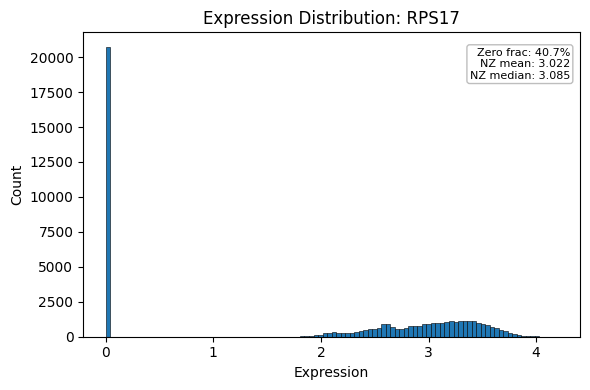

In [77]:

# Highest-variance gene histogram across cells
gene_variances = top5k_matrix.var(axis=0)
hv_idx = int(np.argmax(gene_variances))
hv_gene = top5k_gene_names[hv_idx]
hv_var = gene_variances[hv_idx]
hv_expr = top5k_matrix[:, hv_idx]

zero_frac = (hv_expr == 0).mean()
nonzero = hv_expr[hv_expr > 0]

fig_hv, ax_hv = plt.subplots(figsize=(6,4))
ax_hv.hist(hv_expr, bins=100, color="tab:blue", edgecolor="black", linewidth=0.4)
ax_hv.set_title(f"Expression Distribution: {hv_gene}")
ax_hv.set_xlabel("Expression")
ax_hv.set_ylabel("Count")
ax_hv.text(
0.98, 0.95,
f"Zero frac: {zero_frac*100:.1f}%\nNZ mean: {nonzero.mean():.3f}\nNZ median: {np.median(nonzero):.3f}",
transform=ax_hv.transAxes,
ha="right", va="top", fontsize=8,
bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.85)
)
plt.tight_layout()
plt.show()


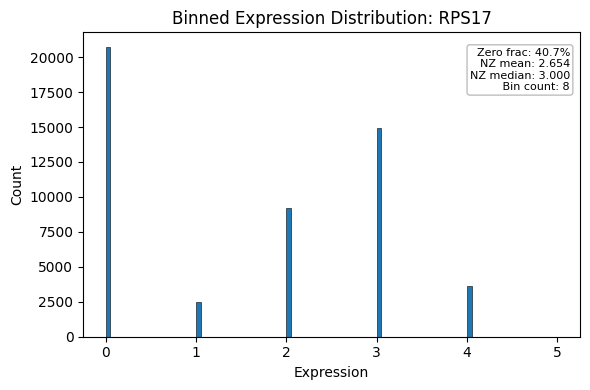

In [78]:

# Highest-variance gene histogram across cells
gene_variances = top5k_bins_tf.var(axis=0)
hv_idx = int(np.argmax(gene_variances))
hv_gene = top5k_gene_names[hv_idx]
hv_var = gene_variances[hv_idx]
hv_expr = top5k_bins_tf[:, hv_idx]

zero_frac = (hv_expr == 0).mean()
nonzero = hv_expr[hv_expr > 0]

fig_hv, ax_hv = plt.subplots(figsize=(6,4))
ax_hv.hist(hv_expr, bins=100, color="tab:blue", edgecolor="black", linewidth=0.4)
ax_hv.set_title(f"Binned Expression Distribution: {hv_gene}")
ax_hv.set_xlabel("Expression")
ax_hv.set_ylabel("Count")
ax_hv.text(
    0.98, 0.95,
    f"Zero frac: {zero_frac*100:.1f}%\nNZ mean: {nonzero.mean():.3f}\nNZ median: {np.median(nonzero):.3f}\n Bin count: {num_bins}",
    transform=ax_hv.transAxes,
    ha="right", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.85)
)
plt.tight_layout()
plt.show()

Highest mean gene: MALAT1
Mean (all cells): 4.0770
Zero fraction: 0.0018
Non-zero count: 50835
Non-zero mean: 4.0846, median: 4.0892


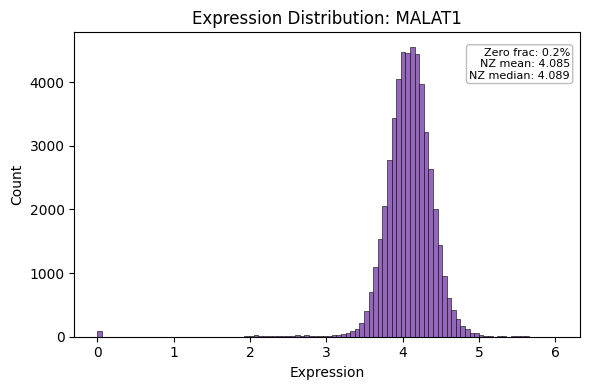

In [79]:
# Gene with highest average (mean) expression across cells (including zeros)
bin_count = 100
gene_means = top5k_matrix.mean(axis=0)
hm_idx = int(np.argmax(gene_means))
hm_gene = top5k_gene_names[hm_idx]
hm_mean = gene_means[hm_idx]
hm_expr = top5k_matrix[:, hm_idx]

hm_zero_frac = (hm_expr == 0).mean()
hm_nonzero = hm_expr[hm_expr > 0]

fig_hmean, ax_hmean = plt.subplots(figsize=(6,4))
ax_hmean.hist(hm_expr, bins=bin_count, color="tab:purple", edgecolor="black", linewidth=0.4)
ax_hmean.set_title(f"Expression Distribution: {hm_gene}")
ax_hmean.set_xlabel("Expression")
ax_hmean.set_ylabel("Count")

ax_hmean.text(
    0.98, 0.95,
    f"Zero frac: {hm_zero_frac*100:.1f}%\nNZ mean: {hm_nonzero.mean():.3f}\nNZ median: {np.median(hm_nonzero):.3f}",
    transform=ax_hmean.transAxes,
    ha="right", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.85)
)

print(f"Highest mean gene: {hm_gene}")
print(f"Mean (all cells): {hm_mean:.4f}")
print(f"Zero fraction: {hm_zero_frac:.4f}")
print(f"Non-zero count: {hm_nonzero.size}")
print(f"Non-zero mean: {hm_nonzero.mean():.4f}, median: {np.median(hm_nonzero):.4f}")

plt.tight_layout()
plt.show()

Highest mean gene: MALAT1
Mean (all cells): 4.3921
Zero fraction: 0.0018
Non-zero count: 50835
Non-zero mean: 4.4002, median: 4.0000


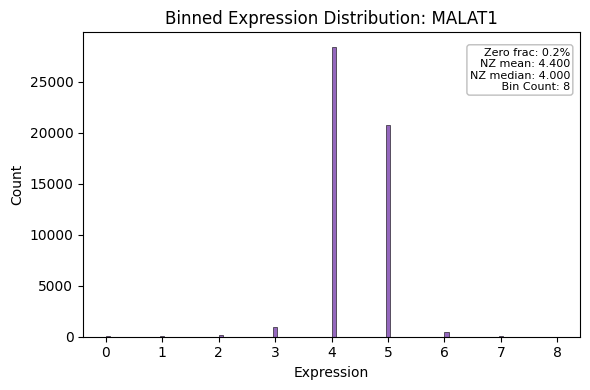

In [82]:
# Gene with highest average (mean) expression across cells (including zeros)
bin_count = 100
gene_means = top5k_bins_tf.mean(axis=0)
hm_idx = int(np.argmax(gene_means))
hm_gene = top5k_gene_names[hm_idx]
hm_mean = gene_means[hm_idx]
hm_expr = top5k_bins_tf[:, hm_idx]

hm_zero_frac = (hm_expr == 0).mean()
hm_nonzero = hm_expr[hm_expr > 0]

fig_hmean, ax_hmean = plt.subplots(figsize=(6,4))
ax_hmean.hist(hm_expr, bins=bin_count, color="tab:purple", edgecolor="black", linewidth=0.4)
ax_hmean.set_title(f"Binned Expression Distribution: {hm_gene}")
ax_hmean.set_xlabel("Expression")
ax_hmean.set_ylabel("Count")

ax_hmean.text(
    0.98, 0.95,
    f"Zero frac: {hm_zero_frac*100:.1f}%\nNZ mean: {hm_nonzero.mean():.3f}\nNZ median: {np.median(hm_nonzero):.3f}\n Bin Count: {num_bins}",
    transform=ax_hmean.transAxes,
    ha="right", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.85)
)

print(f"Highest mean gene: {hm_gene}")
print(f"Mean (all cells): {hm_mean:.4f}")
print(f"Zero fraction: {hm_zero_frac:.4f}")
print(f"Non-zero count: {hm_nonzero.size}")
print(f"Non-zero mean: {hm_nonzero.mean():.4f}, median: {np.median(hm_nonzero):.4f}")

plt.tight_layout()
plt.show()

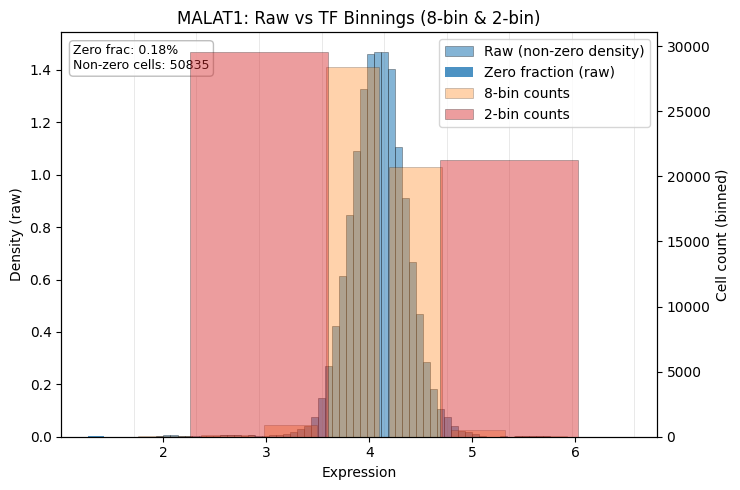

In [100]:
# Overlay MALAT1 raw (continuous) vs 8-bin TF and 2-bin TF distributions

malat1_raw = top5k_matrix[:, malat1_idx]
malat1_binned_8 = top5k_bins_tf[:, malat1_idx]      # 8-bin (num_bins)
malat1_binned_2 = top5k_bins_tf_2[:, malat1_idx]    # 2-bin (num_bins_2)

# Global bin edges (8-bin) reconstruction (linear)
_all_nz = top5k_matrix[top5k_matrix > 0]
global_min = _all_nz.min()
global_max = _all_nz.max()
tf_edges = np.linspace(global_min, global_max, num_bins + 1)
tf_centers = 0.5 * (tf_edges[:-1] + tf_edges[1:])

# Use existing 2-bin edges/centers if available; else derive
try:
    tf_edges_2
    tf_centers_2
except NameError:
    tf_edges_2 = np.linspace(global_min, global_max, num_bins_2 + 1)
    tf_centers_2 = 0.5 * (tf_edges_2[:-1] + tf_edges_2[1:])

# Counts per non-zero bin (exclude zero structural)
bin_counts_8 = np.array([(malat1_binned_8 == k).sum() for k in range(1, num_bins + 1)])
bin_counts_2 = np.array([(malat1_binned_2 == k).sum() for k in range(1, num_bins_2 + 1)])

zero_count = (malat1_binned_8 == 0).sum()  # same zeros across binnings
total_cells = malat1_binned_8.size
zero_frac = zero_count / total_cells

fig_malat1_overlay, ax = plt.subplots(figsize=(7.5, 5))

# Raw non-zero histogram (density)
nz_raw = malat1_raw[malat1_raw > 0]
ax.hist(
    nz_raw,
    bins=60,
    color="tab:blue",
    alpha=0.55,
    density=True,
    edgecolor="black",
    linewidth=0.4,
    label="Raw (non-zero density)"
)

# Zero fraction bar
ax.bar(
    global_min - (tf_edges[1] - tf_edges[0]) * 0.6,
    zero_frac,
    width=(tf_edges[1] - tf_edges[0]) * 0.25,
    color="tab:blue",
    alpha=0.8,
    label="Zero fraction (raw)"
)

ax.set_xlabel("Expression")
ax.set_ylabel("Density (raw)")
ax.set_title("MALAT1: Raw vs TF Binnings (8-bin & 2-bin)")

# Secondary axis for binned counts
ax2 = ax.twinx()

# 8-bin bars
ax2.bar(
    tf_centers,
    bin_counts_8,
    width=(tf_edges[1] - tf_edges[0]) * 0.85,
    color="tab:orange",
    alpha=0.35,
    edgecolor="black",
    linewidth=0.4,
    label="8-bin counts"
)

# 2-bin bars (slightly different styling)
ax2.bar(
    tf_centers_2,
    bin_counts_2,
    width=(tf_edges_2[1] - tf_edges_2[0]) * 0.55,
    color="tab:red",
    alpha=0.45,
    edgecolor="black",
    linewidth=0.4,
    label="2-bin counts"
)

ax2.set_ylabel("Cell count (binned)")

# Bin edge reference lines (8-bin)
for e in tf_edges:
    ax.axvline(e, color="gray", lw=0.4, alpha=0.30)

# Annotations
ax.text(
    0.02, 0.97,
    f"Zero frac: {zero_frac*100:.2f}%\nNon-zero cells: {total_cells - zero_count}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.85)
)


# Combined legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper right", frameon=True)

plt.tight_layout()